# Business Case - Description

In this section, our business case is outlined in bullet points.

The officially binding description is written in our report, however, this line of thoughts may be of use in understanding the backgrounds of our business case.

## 1. Business Context & Problem

- EV charging hubs face strong temporal fluctuations in demand

- Peak utilization can exceed grid capacity or contracted power limits

- Grid congestion leads to:

    - Higher peak demand charges

    - Risk of throttling or outages

- At the same time:

    - Off-peak hours are often underutilized

    - Static pricing and reactive load management are insufficient

## 2. Proposed Business Case

- Introduce an integrated dynamic pricing and smart load management system

- Adjust charging prices and power allocation based on predicted utilization

- Two coordinated actions:

    - Higher prices / controlled charging during predicted peak hours

    - Lower prices / relaxed power constraints during predicted low-load periods

- Target both:

    - User behavior (price incentives)

    - System behavior (load control)

## 3. Role of Utilization Prediction

- Predict site-level hourly utilization ahead of time

- Enable proactive decisions:

    - Set time-of-use prices in advance

    - Schedule load limits before congestion occurs

- Historical averages are insufficient due to:

    - Weather effects

    - Combining effects of various patterns (Time-of-day, weekday, seasonal ...)

## 4. Expected Business Impact

- Increased utilization during off-peak hours

- Data-based profit maximizing

- Reduced peak load and grid stress

- Lower electricity and demand charges

- More predictable and stable hub operation

- Improved long-term infrastructure planning

## 5. Outlook on Other Tasks

Task 4b:

- Develop the prediction model for hourly utilization

Task 4c:

- Example of how predictions inform pricing and load-control decisions

- Discuss risks, limitations, and user response uncertainty

# Business Case - Statistics

In this section, specific visualizations are created to underline the selection of our business case and the selection of the site for that business case.

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Preperation

In [17]:
site1 = pd.read_csv("FINAL1.csv")
site2 = pd.read_csv("FINAL2.csv")

## Data Visualization

In [ ]:
def plot_weekday_rain_vs_no_rain_two_sites(
    df_left, df_right,
    site_left="Site A", site_right="Site B"
):
    def prepare_hourly_averages(df):
        df = df.copy()

        # keep only weekdays (Mon–Fri)
        df = df[df["weekday"].isin([0, 1, 2, 3, 4])]

        # split by rain condition
        df_rain = df[df["precipitation"] > 0.0]
        df_no_rain = df[df["precipitation"] == 0.0]

        # compute hourly averages
        rain_avg = (
            df_rain
            .groupby("hour")["total minutes of parking"]
            .mean()
        )

        no_rain_avg = (
            df_no_rain
            .groupby("hour")["total minutes of parking"]
            .mean()
        )

        return rain_avg, no_rain_avg

    # prepare data
    rain_left, no_rain_left = prepare_hourly_averages(df_left)
    rain_right, no_rain_right = prepare_hourly_averages(df_right)

    # create side-by-side plots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), sharey=True)

    # left plot
    axes[0].plot(rain_left.index, rain_left.values, label="Rain")
    axes[0].plot(no_rain_left.index, no_rain_left.values, linestyle="--", label="No rain")
    axes[0].set_title(site_left)
    axes[0].set_xlabel("Hour of day")
    axes[0].set_ylabel("Average total minutes of parking")
    axes[0].legend()

    # right plot
    axes[1].plot(rain_right.index, rain_right.values, label="Rain")
    axes[1].plot(no_rain_right.index, no_rain_right.values, linestyle="--", label="No rain")
    axes[1].set_title(site_right)
    axes[1].set_xlabel("Hour of day")
    axes[1].legend()

    fig.suptitle(
        "Weekday (Mon-Fri) Total Minutes of Parking by Hour\nRain vs No Rain",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


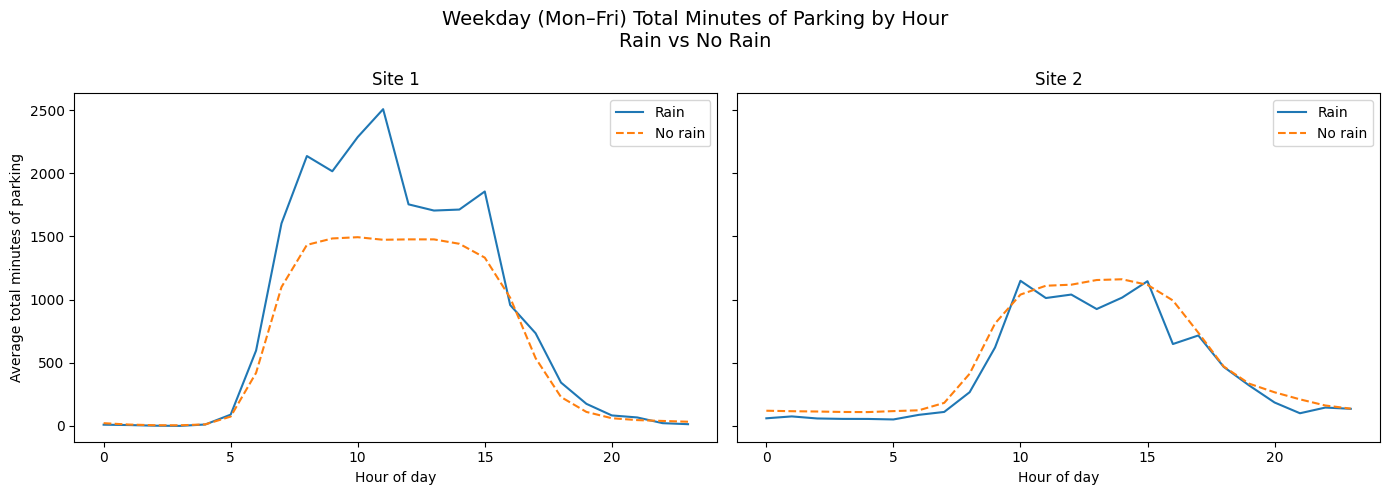

In [40]:
plot_weekday_rain_vs_no_rain_two_sites(site1, site2, "Site 1", "Site 2")

Considering the site characteristics of Site 1, it is likely to be a private company parking site, due to its 9-5 shaped patterns on weekdays.

Logically, it makes sense that bad weather has a large impact on whether an employee uses an EV or a bike for commuting, explaining the high sensitivity to rain.

This resulting plot further validates our business case for Site 1. The customer behaviour seems to be sensitive to bad weather (i.e. rain), even more than Site 2 in comparison. Hence, a prediction model that inlcudes weather data (like our neural network) seems to have a large potential business impact for the owner of Site 1 specifically.